In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import efficientnet_v2_m
import matplotlib.pyplot as plt
import time
import copy

# Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Number of GPUs used: {torch.cuda.device_count()}")


In [ ]:
# Data Augmentation
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

# Load Dataset
train_dataset = datasets.CIFAR100(root='./data', train=True, transform=transform_train, download=True)
test_dataset = datasets.CIFAR100(root='./data', train=False, transform=transform_test, download=True)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=4, pin_memory=True)


In [ ]:
# Model Definition
# Load EfficientNet-L
model = efficientnet_v2_m(weights='IMAGENET1K_V1')

# Replace classifier for CIFAR100
model.classifier[1] = nn.Sequential(
    nn.Dropout(p=0.5),  # Dropout to reduce overfitting
    nn.Linear(model.classifier[1].in_features, 100)  # Adjust for 100 classes
)
model = model.to(device)


# Use DataParallel for multi-GPU training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model = torch.nn.DataParallel(model)  # Wrap the model

# Loss, Optimizer, and Scheduler
criterion = torch.nn.CrossEntropyLoss().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.1, steps_per_epoch=len(train_loader), epochs=100)

# Mixed Precision Training
scaler = GradScaler()


In [ ]:
# Training and Evaluation
epochs = 100
training_acc, testing_acc = [], []

for epoch in range(epochs):
    model.train()
    epoch_loss, correct, total = 0, 0, 0

    start_time = time.time()
    for images, labels in train_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Metrics
        epoch_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_train_acc = 100. * correct / total
    training_acc.append(epoch_train_acc)
    print(f"Epoch {epoch+1}/{epochs}: Train Acc: {epoch_train_acc:.2f}%")
    scheduler.step()

    # Evaluation every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == epochs - 1:
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        acc = 100. * correct / total
        testing_acc.append(acc)
        print(f"Epoch {epoch+1}/{epochs}: Test Acc: {acc:.2f}%")
    
    end_time = time.time()
    print(f"Epoch {epoch+1} completed in {end_time - start_time:.2f} seconds.")


# The whole code

In [ ]:
# Plot training and testing accuracy
plt.figure(figsize=(10, 5))
plt.plot(range(len(training_acc)), training_acc, label="Training Accuracy")
plt.plot(range(0, len(training_acc), 5), testing_acc, label="Testing Accuracy", marker="o")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training and Testing Accuracy")
plt.legend()
plt.show()


# ResNext50

In [ ]:
"""resnext in pytorch



[1] Saining Xie, Ross Girshick, Piotr Dollár, Zhuowen Tu, Kaiming He.

    Aggregated Residual Transformations for Deep Neural Networks
    https://arxiv.org/abs/1611.05431
"""

import math
import torch
import torch.nn as nn
import torch.nn.functional as F

#only implements ResNext bottleneck c


#"""This strategy exposes a new dimension, which we call “cardinality”
#(the size of the set of transformations), as an essential factor
#in addition to the dimensions of depth and width."""
CARDINALITY = 32
DEPTH = 4
BASEWIDTH = 64

#"""The grouped convolutional layer in Fig. 3(c) performs 32 groups
#of convolutions whose input and output channels are 4-dimensional.
#The grouped convolutional layer concatenates them as the outputs
#of the layer."""

class ResNextBottleNeckC(nn.Module):

    def __init__(self, in_channels, out_channels, stride):
        super().__init__()

        C = CARDINALITY #How many groups a feature map was splitted into

        #"""We note that the input/output width of the template is fixed as
        #256-d (Fig. 3), We note that the input/output width of the template
        #is fixed as 256-d (Fig. 3), and all widths are dou- bled each time
        #when the feature map is subsampled (see Table 1)."""
        D = int(DEPTH * out_channels / BASEWIDTH) #number of channels per group
        self.split_transforms = nn.Sequential(
            nn.Conv2d(in_channels, C * D, kernel_size=1, groups=C, bias=False),
            nn.BatchNorm2d(C * D),
            nn.ReLU(inplace=True),
            nn.Conv2d(C * D, C * D, kernel_size=3, stride=stride, groups=C, padding=1, bias=False),
            nn.BatchNorm2d(C * D),
            nn.ReLU(inplace=True),
            nn.Conv2d(C * D, out_channels * 4, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels * 4),
        )

        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels * 4:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * 4, stride=stride, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels * 4)
            )

    def forward(self, x):
        return F.relu(self.split_transforms(x) + self.shortcut(x))

class ResNext(nn.Module):

    def __init__(self, block, num_blocks, class_names=100):
        super().__init__()
        self.in_channels = 64

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        self.conv2 = self._make_layer(block, num_blocks[0], 64, 1)
        self.conv3 = self._make_layer(block, num_blocks[1], 128, 2)
        self.conv4 = self._make_layer(block, num_blocks[2], 256, 2)
        self.conv5 = self._make_layer(block, num_blocks[3], 512, 2)
        self.avg = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * 4, 100)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.avg(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

    def _make_layer(self, block, num_block, out_channels, stride):
        """Building resnext block
        Args:
            block: block type(default resnext bottleneck c)
            num_block: number of blocks per layer
            out_channels: output channels per block
            stride: block stride

        Returns:
            a resnext layer
        """
        strides = [stride] + [1] * (num_block - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels * 4

        return nn.Sequential(*layers)

def resnext50():
    """ return a resnext50(c32x4d) network
    """
    return ResNext(ResNextBottleNeckC, [3, 4, 6, 3])

def resnext101():
    """ return a resnext101(c32x4d) network
    """
    return ResNext(ResNextBottleNeckC, [3, 4, 23, 3])

def resnext152():
    """ return a resnext101(c32x4d) network
    """
    return ResNext(ResNextBottleNeckC, [3, 4, 36, 3])


# Training CIFAR-100 with Pretrained ResNet-50
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet50
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torchvision
import matplotlib.pyplot as plt

# Configuration
batch_size = 512
learning_rate = 0.1 * (batch_size / 256)  # Scale LR based on batch size
num_epochs = 150
warmup_epochs = 5
milestones = [60, 120]  # Adjust for 150 epochs
gamma = 0.1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data augmentation and normalization for CIFAR-100
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
])

train_dataset = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

# Load ResNet-50 pretrained on ImageNet
# model = resnet50(weights="IMAGENET1K_V1")  # Use pre-trained weights
# model.fc = nn.Linear(2048, 100)  # Replace final fully connected layer for CIFAR-100
model = resnext50()
model = nn.DataParallel(model).to(device)  # Use DataParallel for multi-GPU training

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=5e-4)

# Learning rate schedulers
iter_per_epoch = len(train_loader)
warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer, lambda epoch: epoch / (iter_per_epoch * warmup_epochs) if epoch <= iter_per_epoch * warmup_epochs else 1
)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=milestones, gamma=gamma)

# Training and evaluation functions
def train_one_epoch(epoch):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return correct / total, total_loss / total

@torch.no_grad()
def evaluate():
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return correct / total, total_loss / total

# Training loop
train_accuracies, val_accuracies = [], []
train_losses, val_losses = [], []

for epoch in range(1, num_epochs + 1):
    print(f"Epoch {epoch}/{num_epochs}")

    # Adjust LR during warmup
    if epoch <= warmup_epochs:
        warmup_scheduler.step()

    # Train and evaluate
    train_acc, train_loss = train_one_epoch(epoch)
    val_acc, val_loss = evaluate()

    # Log metrics
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Step learning rate scheduler
    if epoch > warmup_epochs:
        scheduler.step()

    # Print progress
    print(f"Train Accuracy: {train_acc*100:.4f}%, Train Loss: {train_loss:.4f}")
    print(f"Val Accuracy: {val_acc*100:.4f}%, Val Loss: {val_loss:.4f}")

# Plotting training and validation metrics
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Over Epochs')

plt.subplot(1, 2, 2)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Over Epochs')

plt.tight_layout()
plt.show()


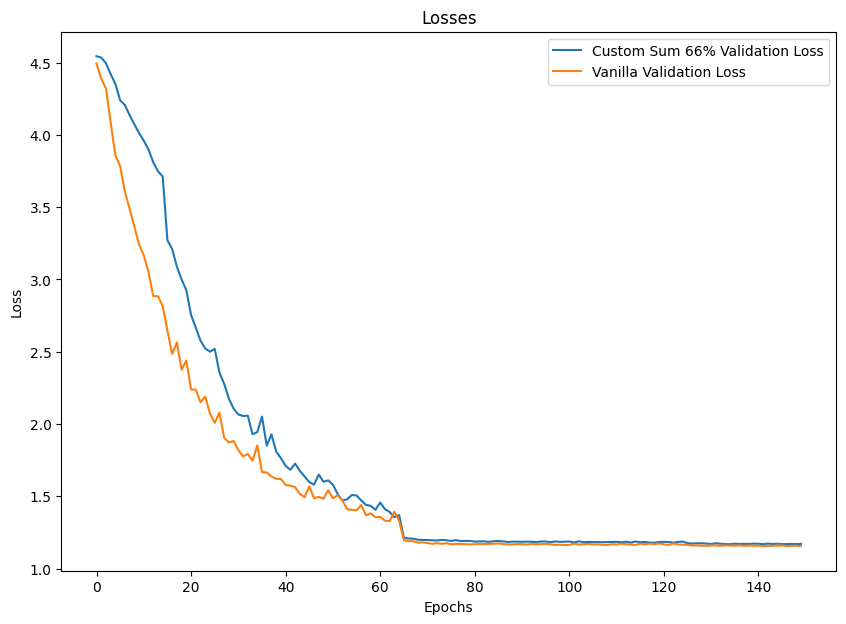

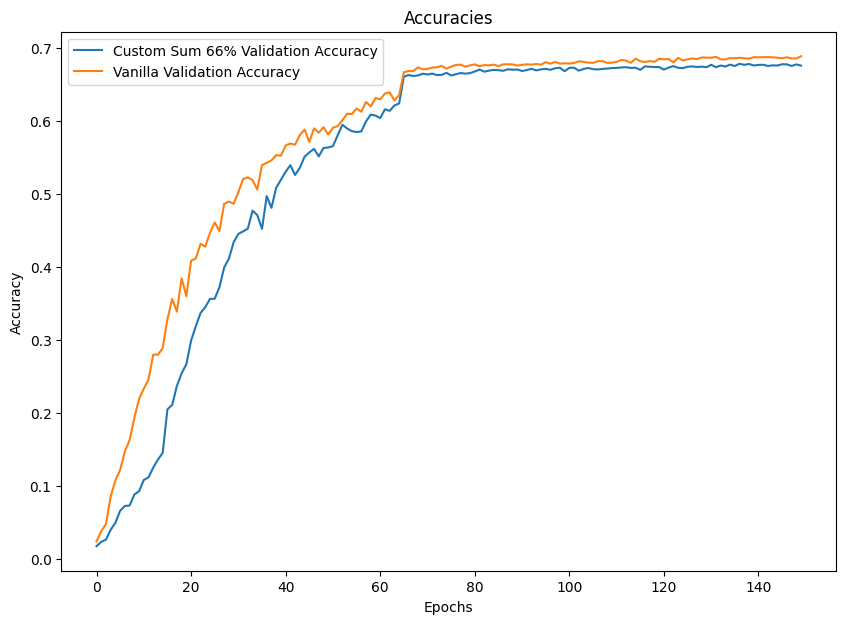

In [4]:
import matplotlib.pyplot as plt
import numpy as np
custom_train_losses = np.load('./logs/train_loss.npy')
custom_test_losses = np.load('./logs/val_loss.npy')
custom_test_accuracies = np.load('./logs/val_acc.npy')
custom_train_accuracies = np.load('./logs/train_acc.npy')

vanilla_train_losses = np.load('./logs/vanilla_train_loss.npy')
vanilla_test_losses = np.load('./logs/vanilla_val_loss.npy')
vanilla_test_accuracies = np.load('./logs/vanilla_val_acc.npy')
vanilla_train_accuracies = np.load('./logs/vanilla_train_acc.npy')

#Plot Losses
plt.figure(figsize=(10, 7))
# plt.plot(custom_train_losses, label='Custom Sum 66% Training Loss')
plt.plot(custom_test_losses, label='Custom Sum 66% Validation Loss')
# plt.plot(vanilla_train_losses, label='Vanilla Training Loss')
plt.plot(vanilla_test_losses, label='Vanilla Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Losses')
plt.show()

#Plot Accuracies
plt.figure(figsize=(10, 7))
# plt.plot(custom_train_accuracies, label='Custom Sum 66% Training Accuracy')
plt.plot(custom_test_accuracies, label='Custom Sum 66% Validation Accuracy')
# plt.plot(vanilla_train_accuracies, label='Vanilla Training Accuracy')
plt.plot(vanilla_test_accuracies, label='Vanilla Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracies')
plt.show()
